In [1]:
import pandas as pd
from pipeline import create_X_y_df
import numpy as np

In [2]:
df_full = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [3]:
df = df_full.copy()

In [4]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-11-05")
cut_off_date_test = pd.Timestamp("2018-11-15")

df_X, df_y = create_X_y_df(df = df,
                                t0=cut_off_date_train,
                                t1=cut_off_date_test)

In [ ]:
df_X[df_X["status"]]

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration,date
23740332,200,F,Melody,paid,Gordon,1766069,1539702448000,Logged In,NextSong,14818,"Pecos, TX",0,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",PUT,294.05995,Darkness Before Dawn,Killing Joke,2018-10-16 15:07:28,2018-09-09 15:49:25,2018-10-16 15:07:28
7733686,200,M,Jayden,paid,Hensley,1366835,1540370057000,Logged In,NextSong,107655,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",32,Mozilla/5.0 (Windows NT 6.1; rv:31.0) Gecko/20...,PUT,227.47383,Those Were The Days,Lady Sovereign,2018-10-24 08:34:17,2018-09-19 05:51:57,2018-10-24 08:34:17
5288406,200,M,Jonathan,paid,Chavez,1837563,1539752867000,Logged In,NextSong,89686,"Oklahoma City, OK",2,"""Mozilla/5.0 (iPad; CPU OS 7_1_2 like Mac OS X...",PUT,259.05587,Intervention,Arcade Fire,2018-10-17 05:07:47,2018-08-28 05:02:04,2018-10-17 05:07:47
23339014,200,M,Christopher,paid,Robinson,1039630,1539097996000,Logged In,NextSong,8185,"Grand Rapids-Wyoming, MI",15,"""Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/5...",PUT,213.08036,Gives You Hell,The All-American Rejects,2018-10-09 15:13:16,2018-08-19 06:26:43,2018-10-09 15:13:16
20601270,200,M,Jackson,paid,Sanchez,1474833,1540391620000,Logged In,NextSong,11585,"Augusta-Richmond County, GA-SC",44,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,266.63138,Winter Song,Sara Bareilles,2018-10-24 14:33:40,2018-09-22 19:31:58,2018-10-24 14:33:40
6303957,200,M,Sergio,free,Hunt,1086327,1539976391000,Logged In,NextSong,93880,"Bridgeport-Stamford-Norwalk, CT",6,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,PUT,231.86240,Lovesick,Grand Duchy,2018-10-19 19:13:11,2018-08-15 10:23:51,2018-10-19 19:13:11
177272,200,M,Jaydon,free,Martinez,1520243,1538410194000,Logged In,Home,21975,"Miami-Fort Lauderdale-West Palm Beach, FL",66,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",GET,NaN,None,None,2018-10-01 16:09:54,2018-05-27 01:08:02,2018-10-01 16:09:54
387582,200,F,Gracie,paid,Curtis,1983673,1538466010000,Logged In,NextSong,6094,"Norwich-New London, CT",296,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,227.36934,Under Pressure,Queen,2018-10-02 07:40:10,2018-07-15 14:08:41,2018-10-02 07:40:10
6221950,200,F,Haley,paid,King,1927165,1539961372000,Logged In,NextSong,87880,"Rapid City, SD",35,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,234.05669,Life's Too Long (To Live Like This),Ricky Skaggs,2018-10-19 15:02:52,2018-09-16 17:20:34,2018-10-19 15:02:52
6918391,200,M,Angel,paid,House,1388244,1540184904000,Logged In,NextSong,108927,"Beaumont-Port Arthur, TX",46,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,PUT,237.47873,Flashing Lights,Kanye West,2018-10-22 05:08:24,2018-09-15 05:54:30,2018-10-22 05:08:24


In [6]:
df_X["status"].unique()

array([200, 307, 404])

In [8]:
df_X[df_X["status"] == 307]["page"].unique()

array(['Thumbs Up', 'Thumbs Down', 'Add Friend', 'Logout',
       'Submit Downgrade', 'Submit Upgrade', 'Save Settings'],
      dtype=object)

In [21]:
df_a = df_X.groupby(["userId","status"]).size().reset_index(name="num")

In [22]:
df_b = df_a.merge(df_y, on = "userId")

In [23]:
df_b

,userId,status,num,Cancellation Confirmation
0,1000035,200,818,0
1,1000035,307,97,0
2,1000103,200,63,0
3,1000103,307,5,0
4,1000164,200,420,0
...,...,...,...,...
36405,1999848,200,523,0
36406,1999848,307,58,0
36407,1999848,404,1,0
36408,1999905,200,285,0


In [29]:
df_b

,userId,status,num,Cancellation Confirmation
0,1000035,200,818,0
1,1000035,307,97,0
2,1000103,200,63,0
3,1000103,307,5,0
4,1000164,200,420,0
...,...,...,...,...
36405,1999848,200,523,0
36406,1999848,307,58,0
36407,1999848,404,1,0
36408,1999905,200,285,0


In [24]:
import seaborn as sns

<Axes: xlabel='Cancellation Confirmation', ylabel='num'>

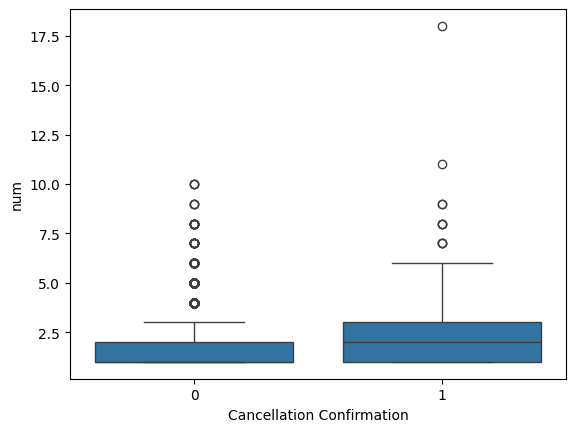

In [30]:
sns.boxplot(df_b[df_b["status"] == 404], x = "Cancellation Confirmation", y = "num")